In [14]:
%pip install -q pandas pypsa numpy matplotlib openpyxl
import pandas as pd
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
plt.rcParams['font.family'] = 'Aptos' if 'Aptos' in _fm.get_font_names() else 'DejaVu Sans'
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════
# ROLLING HORIZON MODEL  —  NL Greenhouse (PyPSA)
#
# Two-stage comparison:
#   Stage 1 (Perfect Foresight): fixed-capacity LP over full year
#   Stage 2 (Rolling Horizon)  : same fixed capacity, 24h window + 12h overlap
#
# Battery sizing comes from a preliminary extendable solve (same LP as
# NL_elec_only, including cycle cap).  The cycle cap is then DROPPED
# from the dispatch solves but tracked post-hoc for both stages.
# ══════════════════════════════════════════════════════════════════════

# ── SCENARIO ────────────────────────────────────────────────────────────────
SCENARIO   = "2025_2026"   # "2025_2026" or "2023"
_FILES = {
    "2025_2026": "Input_Python-NL-Poel8-Heat-20252026.xlsx",
    "2023":      "Input_Python-NL-Poel8-heat-2023.xlsx",
}
INPUT_FILE   = _FILES[SCENARIO]
OUTPUT_EXCEL = f"nl_elec_only_rolling_{SCENARIO}.xlsx"

# ── SITE ─────────────────────────────────────────────────────────────────────
GREENHOUSE_HA  = 5.2
COL_DA_PRICE   = "Day-ahead price (EUR/kWh)"
COL_PV_PROFILE = "Production voltiron (W)"
COL_LOAD       = "Loadcurve (kW)"
COL_MONTH, COL_DAY, COL_HOUR, COL_MINUTE = "Month", "Day", "Hour", "Minute"

YEAR       = 2025
DT         = 0.25   # 15-min timestep in hours
DT_H       = 1.0    # hourly timestep (model runs hourly)
PV_MODULES = int(2500 * GREENHOUSE_HA)
MODULE_WP  = 145

# ── PRICES ───────────────────────────────────────────────────────────────────
ENERGY_TAX = 37.35 / 1000   # EUR/kWh  (energiebelasting 2026, staffel 4)
TRANSPORT  = 24.20 / 1000   # EUR/kWh  (Westland Infra MS, 2026)

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── BATTERY ──────────────────────────────────────────────────────────────────
BATTERY_EFFICIENCY_STORE    = 0.98
BATTERY_EFFICIENCY_DISPATCH = 0.97
BATTERY_LIFE_YR             = 20
MAX_CYCLES_PER_YEAR         = 6000 / 20   # 333/yr — tracking reference only
BATTERY_SELF_DISCHARGE_HR   = 0.1 / 100 / 24

# ── GRID ─────────────────────────────────────────────────────────────────────
GRID_IMPORT_MAX_KW = 1372.0
GRID_EXPORT_MAX_KW = 1940.0

# ── CAPEX ─────────────────────────────────────────────────────────────────────
BATTERY_BENCHMARK_KWH         = 3_600
BATTERY_BENCHMARK_MW          = 3.6
BATTERY_CAPEX_ENERGY_MEUR_MWH = 0.065
BATTERY_CAPEX_POWER_MEUR_MW   = 0.084
BATTERY_CAPEX_OTHER_MEUR_MWH  = 0.13
BATTERY_SUBSIDY_FRAC          = 0.0
BATTERY_OM_KEUR_MW_YR         = 8.1
EXPANSION_ENERGY_MEUR_MWH     = 0.084
EXPANSION_POWER_MEUR_MW       = 0.108
OUTAGE_WEEKS                  = 0.2

# ── ROLLING HORIZON PARAMETERS ────────────────────────────────────────────────
RH_HORIZON  = 24   # hours committed per window (day-ahead decision)
RH_OVERLAP  = 12   # extra hours the optimizer sees (boundary smoothing)


# ══════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════

df = pd.read_excel(INPUT_FILE)
df["timestamp"] = pd.to_datetime(
    dict(year=YEAR, month=df[COL_MONTH], day=df[COL_DAY],
         hour=df[COL_HOUR], minute=df[COL_MINUTE])
)
df = df.set_index("timestamp")
df.index = pd.date_range("2025-01-01 00:00", periods=len(df), freq="15min")

pv_kw        = (df[COL_PV_PROFILE] / 1000) * PV_MODULES
load_kw      = df[COL_LOAD] / DT
da_price     = df[COL_DA_PRICE].fillna(0)
import_price = da_price + ENERGY_TAX + TRANSPORT

pv_kwh   = pv_kw   * DT
load_kwh = load_kw * DT

pv_surplus_kw   = (pv_kw   - load_kw).clip(lower=0)
load_deficit_kw = (load_kw - pv_kw  ).clip(lower=0)
export_rev_ts   = pv_surplus_kw   * DT * da_price
import_cost_ts  = load_deficit_kw * DT * import_price
net_revenue_ts  = export_rev_ts - import_cost_ts
baseline_annual_net = net_revenue_ts.sum()

eta2 = BATTERY_EFFICIENCY_STORE * BATTERY_EFFICIENCY_DISPATCH


# ══════════════════════════════════════════════════════════════════════
# CAPEX HELPERS
# ══════════════════════════════════════════════════════════════════════

def gross_capex(energy_kwh, power_kw):
    _bm_e = BATTERY_BENCHMARK_KWH
    _bm_p = BATTERY_BENCHMARK_MW * 1e3
    bm    = ((BATTERY_CAPEX_ENERGY_MEUR_MWH + BATTERY_CAPEX_OTHER_MEUR_MWH) * _bm_e / 1e3
             + BATTERY_CAPEX_POWER_MEUR_MW * _bm_p / 1e3) * 1e6
    exp_e = EXPANSION_ENERGY_MEUR_MWH * max(0.0, energy_kwh - _bm_e) / 1e3 * 1e6
    exp_p = EXPANSION_POWER_MEUR_MW   * max(0.0, power_kw  - _bm_p) / 1e3 * 1e6
    return bm + exp_e + exp_p

def net_capex(energy_kwh, power_kw):
    return gross_capex(energy_kwh, power_kw) * (1 - BATTERY_SUBSIDY_FRAC)

def annual_om(power_kw):
    return BATTERY_OM_KEUR_MW_YR * (power_kw / 1e3) * 1e3


# ══════════════════════════════════════════════════════════════════════
# HOURLY SERIES  (model runs at 1h timestep)
# ══════════════════════════════════════════════════════════════════════

_PV_NOM_KW    = float(pv_kw.max())
_PV_PU        = (pv_kw / _PV_NOM_KW).clip(upper=1.0)
_BAT_OFF      = int(round(OUTAGE_WEEKS * 7 * 24 / DT))
_BAT_MAX_PU   = pd.Series(1.0, index=df.index)

_OUTAGE_START = pd.Timestamp(f"{df.index[0].year}-08-25")
if _OUTAGE_START < df.index[0]:
    _OUTAGE_START = pd.Timestamp(f"{df.index[0].year + 1}-08-25")
_OUTAGE_IDX   = int(df.index.searchsorted(_OUTAGE_START))
_BAT_MAX_PU.iloc[_OUTAGE_IDX : _OUTAGE_IDX + _BAT_OFF] = 0.0

_H              = pd.date_range(df.index[0], periods=len(df)//4, freq="h")
_PV_PU_H        = _PV_PU.resample("h").mean()
_load_kw_H      = load_kw.resample("h").mean()
_import_price_H = import_price.resample("h").mean()
_da_price_H     = da_price.resample("h").mean()
_BAT_MAX_PU_H   = _BAT_MAX_PU.resample("h").min()
_P_EXPORT_NOM   = GRID_EXPORT_MAX_KW if GRID_EXPORT_MAX_KW else _PV_NOM_KW * 1.1
_P_IMPORT_ELEC  = GRID_IMPORT_MAX_KW if GRID_IMPORT_MAX_KW else float(load_kw.max()) * 2
_load_mwh_yr    = float((_load_kw_H * DT_H).sum()) / 1000

print(f"Loaded {len(_H)} hourly snapshots  |  PV: {_PV_NOM_KW:,.0f} kW_p  |  Load: {_load_mwh_yr:,.0f} MWh/yr")
print(f"Rolling horizon: {RH_HORIZON}h window + {RH_OVERLAP}h overlap  ({len(_H)//RH_HORIZON} windows/year)")
print(f"MAX_CYCLES_PER_YEAR = {MAX_CYCLES_PER_YEAR:.0f}  (tracking reference, not enforced in dispatch LP)")


Note: you may need to restart the kernel to use updated packages.
Loaded 8760 hourly snapshots  |  PV: 1,178 kW_p  |  Load: 3,282 MWh/yr
Rolling horizon: 24h window + 12h overlap  (365 windows/year)
MAX_CYCLES_PER_YEAR = 300  (tracking reference, not enforced in dispatch LP)


In [15]:
# ══════════════════════════════════════════════════════════════════════
# NETWORK BUILDERS
# ══════════════════════════════════════════════════════════════════════

_bat_store_cap = EXPANSION_ENERGY_MEUR_MWH * 1e6 / 1e3 / BATTERY_LIFE_YR
_bat_link_cap  = ((EXPANSION_POWER_MEUR_MW * 1e6 / 1e3 / BATTERY_LIFE_YR) / 2
                  + BATTERY_OM_KEUR_MW_YR * 1e3 / 1e3 / 2)


def _make_network(snapshots=None, dt=1.0):
    n = pypsa.Network()
    n.set_snapshots(snapshots if snapshots is not None else _H)
    n.snapshot_weightings.loc[:, :] = dt
    return n


def _add_elec_bus(n, p_import, p_export, mc_import, mc_export,
                  pv_pu=None, elec_load=None):
    n.add("Carrier", "electricity")
    n.add("Bus", "elec", carrier="electricity")
    n.add("Generator", "pv", bus="elec", p_nom=_PV_NOM_KW, marginal_cost=0.0)
    n.generators_t.p_max_pu["pv"] = pv_pu if pv_pu is not None else _PV_PU_H
    n.add("Load", "elec_load", bus="elec")
    n.loads_t.p_set["elec_load"] = elec_load if elec_load is not None else _load_kw_H
    n.add("Generator", "grid_import", bus="elec", p_nom=p_import, marginal_cost=0.0)
    n.generators_t.marginal_cost["grid_import"] = mc_import
    n.add("Generator", "grid_export", bus="elec", p_nom=p_export,
          p_min_pu=-1, p_max_pu=0, marginal_cost=0.0)
    n.generators_t.marginal_cost["grid_export"] = mc_export


def _add_battery(n, extendable=True, bat_e=None, bat_p=None,
                 max_pu=None, e_cyclic=True, e_initial=0.0):
    """Add battery as Store + two Links.

    For rolling horizon pass: extendable=False, e_cyclic=False, e_initial=0.5*bat_e.
    PyPSA's optimize_with_rolling_horizon then sets e_initial from the previous
    window's final SOC automatically for windows 2..N.
    """
    n.add("Bus", "battery_bus", carrier="electricity")
    pu = max_pu if max_pu is not None else _BAT_MAX_PU_H

    if extendable:
        n.add("Store", "battery_store", bus="battery_bus",
              e_nom=0, e_nom_min=BATTERY_BENCHMARK_KWH,
              e_nom_extendable=True, e_cyclic=True,
              standing_loss=BATTERY_SELF_DISCHARGE_HR,
              capital_cost=_bat_store_cap, marginal_cost=0.0)
        n.add("Link", "bat_charge", bus0="elec", bus1="battery_bus",
              p_nom=0, p_nom_min=BATTERY_BENCHMARK_MW * 1e3, p_nom_extendable=True,
              efficiency=BATTERY_EFFICIENCY_STORE,
              capital_cost=_bat_link_cap, marginal_cost=0.0)
        n.add("Link", "bat_discharge", bus0="battery_bus", bus1="elec",
              p_nom=0, p_nom_min=BATTERY_BENCHMARK_MW * 1e3, p_nom_extendable=True,
              efficiency=BATTERY_EFFICIENCY_DISPATCH,
              capital_cost=_bat_link_cap, marginal_cost=0.0)
    else:
        n.add("Store", "battery_store", bus="battery_bus",
              e_nom=bat_e, e_cyclic=e_cyclic, e_initial=e_initial,
              standing_loss=BATTERY_SELF_DISCHARGE_HR, marginal_cost=0.0)
        n.add("Link", "bat_charge", bus0="elec", bus1="battery_bus",
              p_nom=bat_p, efficiency=BATTERY_EFFICIENCY_STORE, marginal_cost=0.0)
        n.add("Link", "bat_discharge", bus0="battery_bus", bus1="elec",
              p_nom=bat_p, efficiency=BATTERY_EFFICIENCY_DISPATCH, marginal_cost=0.0)
    n.links_t.p_max_pu["bat_charge"]    = pu
    n.links_t.p_max_pu["bat_discharge"] = pu


def _add_cycle_constraint(n, snapshots):
    """Annual cycle cap — used ONLY in the extendable sizing solve."""
    m = n.model
    if "Link-p" not in m.variables or "battery_store" not in n.stores.index:
        return
    p     = m.variables["Link-p"]
    p_dim = [d for d in p.dims if d != "snapshot"][0]
    if "bat_discharge" not in list(p.coords[p_dim].values):
        return
    dis = p.sel({p_dim: "bat_discharge"})
    if "Store-e_nom" in m.variables:
        e_nom_var = m.variables["Store-e_nom"]
        e_dim     = [d for d in e_nom_var.dims][0]
        bat_e_nom = e_nom_var.sel({e_dim: "battery_store"})
    else:
        bat_e_nom = float(n.stores.at["battery_store", "e_nom"])
    m.add_constraints(
        (dis * DT_H).sum("snapshot") - MAX_CYCLES_PER_YEAR * bat_e_nom <= 0,
        name="max_annual_cycles",
    )
    print(f"  [cycle cap] {MAX_CYCLES_PER_YEAR:.0f} cycles/yr enforced (extendable sizing solve only)")


def _extract_dispatch(n):
    """Return dict of annual dispatch series from a solved network."""
    ei  = n.generators_t.p["grid_import"]
    ee  = (-n.generators_t.p["grid_export"]).clip(lower=0)
    pv  = n.generators_t.p["pv"]
    bc  = n.links_t.p0["bat_charge"]
    bd  = (-n.links_t.p1["bat_discharge"]).clip(lower=0)
    soc = n.stores_t.e["battery_store"]
    return dict(ei=ei, ee=ee, pv=pv, bc=bc, bd=bd, soc=soc)


def _pv_ss_flows(pv_kw, gi_kw, ge_kw, bc_kw, bd_kw, soc_kwh, load_kw, dt_h=1.0):
    """PV self-sufficiency via proportional bus-flow allocation.

    At each hour all sources (PV, grid_import, bat_discharge) mix at the bus
    and flow to sinks (load, bat_charge, grid_export) in proportion.
    PV-origin fraction of battery SOC is tracked step-by-step.
    Returns (ss_pct, sc_pct) — both in percent.
    """
    pv_arr  = pv_kw.values;  gi_arr = gi_kw.values;  ge_arr = ge_kw.values
    bc_arr  = bc_kw.values;  bd_arr = bd_kw.values;  soc_arr = soc_kwh.values
    lk_arr  = load_kw.values
    pv_to_load = 0.0
    pv_in_bat  = 0.0
    prev_soc   = 0.0
    for t in range(len(pv_arr)):
        pv = pv_arr[t]; gi = gi_arr[t]; ge = ge_arr[t]
        bc = bc_arr[t]; bd = bd_arr[t]; soc_end = soc_arr[t]
        lk = lk_arr[t]
        total_supply = pv + gi + bd
        total_demand = lk + bc + ge
        if total_supply < 1e-9 or total_demand < 1e-9:
            prev_soc = soc_end
            continue
        bat_pv_frac = min(pv_in_bat / prev_soc, 1.0) if prev_soc > 0 else 0.0
        pv_origin   = pv + bd * bat_pv_frac
        pv_to_load += pv_origin * (lk / total_demand) * dt_h
        if bc > 0:
            pv_in_bat += (pv / total_supply) * bc * BATTERY_EFFICIENCY_STORE * dt_h
        if bd > 0 and prev_soc > 0:
            pv_in_bat = max(pv_in_bat - bat_pv_frac * (bd / BATTERY_EFFICIENCY_DISPATCH) * dt_h, 0.0)
        pv_in_bat = min(pv_in_bat, soc_end)
        prev_soc  = soc_end
    total_load_kwh = float((load_kw * dt_h).sum())
    total_pv_kwh   = float((pv_kw   * dt_h).sum())
    ss  = pv_to_load / total_load_kwh * 100 if total_load_kwh > 0 else 0.0
    sc  = pv_to_load / total_pv_kwh   * 100 if total_pv_kwh   > 0 else 0.0
    return ss, sc


def _compute_kpis(d, bat_e_kwh, price_import, price_export):
    """Annual KPIs from a dispatch dict.

    SS is computed via proportional bus-flow tracking (same as NL_elec_only).
    The simple formula 1 - import/load is WRONG here because the battery
    charges from the grid for arbitrage, making total import > total load.
    """
    import_cost = float((d["ei"] * price_import * DT_H).sum())
    export_rev  = float((d["ee"] * price_export * DT_H).sum())
    net_cost    = import_cost - export_rev
    ei_mwh      = float((d["ei"] * DT_H).sum()) / 1000
    ee_mwh      = float((d["ee"] * DT_H).sum()) / 1000
    bd_mwh      = float((d["bd"] * DT_H).sum()) / 1000
    cycles      = bd_mwh * 1000 / bat_e_kwh if bat_e_kwh > 0 else 0.0
    ss, sc      = _pv_ss_flows(d["pv"], d["ei"], d["ee"],
                               d["bc"], d["bd"], d["soc"], _load_kw_H)
    return dict(import_cost=import_cost, export_rev=export_rev, net_cost=net_cost,
                ei_mwh=ei_mwh, ee_mwh=ee_mwh, bd_mwh=bd_mwh, cycles=cycles, ss=ss, sc=sc)


# ══════════════════════════════════════════════════════════════════════
# STEP 1: EXTENDABLE SOLVE — find optimal battery size
#         (same LP as NL_elec_only, cycle cap enforced here)
# ══════════════════════════════════════════════════════════════════════

print("Step 1: Extendable solve — finding optimal battery capacity ...")
n_ext = _make_network(_H, dt=1.0)
_add_elec_bus(n_ext, _P_IMPORT_ELEC, _P_EXPORT_NOM, _import_price_H, _da_price_H,
              pv_pu=_PV_PU_H, elec_load=_load_kw_H)
_add_battery(n_ext, extendable=True, max_pu=_BAT_MAX_PU_H)
n_ext.sanitize()
_st, _cd = n_ext.optimize(solver_name="highs", log_to_console=False,
                           extra_functionality=_add_cycle_constraint)
if _st not in ("ok", "warning"):
    raise RuntimeError(f"Extendable solve failed: {_cd}")

bat_e_kwh  = float(n_ext.stores.at["battery_store", "e_nom_opt"])
bat_p_kw   = float(n_ext.links.at["bat_charge",    "p_nom_opt"])
bat_c_rate = bat_p_kw / bat_e_kwh if bat_e_kwh > 0 else 0.0
bat_ann_cap = net_capex(bat_e_kwh, bat_p_kw) / BATTERY_LIFE_YR
bat_fix_eur = annual_om(bat_p_kw)

print(f"  Battery: {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  (C-rate {bat_c_rate:.2f})")
print(f"  Net CAPEX: EUR{net_capex(bat_e_kwh,bat_p_kw):,.0f}  |  Ann. CAPEX: EUR{bat_ann_cap:,.0f}/yr  |  O&M: EUR{bat_fix_eur:,.0f}/yr")


# ══════════════════════════════════════════════════════════════════════
# STEP 2: PERFECT FORESIGHT — full-year LP, fixed capacity
#         (annual cyclic SOC, NO cycle cap in LP)
# ══════════════════════════════════════════════════════════════════════

print("\nStep 2: Perfect Foresight solve (full-year LP, fixed capacity) ...")
n_pf = _make_network(_H, dt=1.0)
_add_elec_bus(n_pf, _P_IMPORT_ELEC, _P_EXPORT_NOM, _import_price_H, _da_price_H,
              pv_pu=_PV_PU_H, elec_load=_load_kw_H)
_add_battery(n_pf, extendable=False, bat_e=bat_e_kwh, bat_p=bat_p_kw,
             max_pu=_BAT_MAX_PU_H, e_cyclic=True)
n_pf.sanitize()
_st_pf, _cd_pf = n_pf.optimize(solver_name="highs", log_to_console=False)
if _st_pf not in ("ok", "warning"):
    raise RuntimeError(f"Perfect foresight solve failed: {_cd_pf}")
print("  -> OK")

d_pf   = _extract_dispatch(n_pf)
kpi_pf = _compute_kpis(d_pf, bat_e_kwh, _import_price_H, _da_price_H)

print(f"  Import cost   : EUR{kpi_pf['import_cost']:>10,.0f}/yr")
print(f"  Export revenue: EUR{kpi_pf['export_rev']:>10,.0f}/yr")
print(f"  Net elec cost : EUR{kpi_pf['net_cost']:>10,.0f}/yr")
print(f"  Battery cycles: {kpi_pf['cycles']:>9.0f}/yr  (cap ref: {MAX_CYCLES_PER_YEAR:.0f})")
print(f"  Self-sufficiency: {kpi_pf['ss']:>6.1f}%  |  Self-consumption: {kpi_pf['sc']:>6.1f}%")


Step 1: Extendable solve — finding optimal battery capacity ...


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.


  [cycle cap] 300 cycles/yr enforced (extendable sizing solve only)


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 205.22it/s]
INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61323 primals, 131404 duals
Objective: 2.91e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, max_annual_cycles were not assigned to the network.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


  Battery: 13,253 kWh / 3,600 kW  (C-rate 0.27)
  Net CAPEX: EUR1,815,263  |  Ann. CAPEX: EUR90,763/yr  |  O&M: EUR29,160/yr

Step 2: Perfect Foresight solve (full-year LP, fixed capacity) ...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 258.58it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61320 primals, 131400 duals
Objective: 1.87e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


  -> OK
  Import cost   : EUR   435,330/yr
  Export revenue: EUR   248,613/yr
  Net elec cost : EUR   186,717/yr
  Battery cycles:       235/yr  (cap ref: 300)
  Self-sufficiency:   15.7%  |  Self-consumption:   35.5%


In [16]:
# ══════════════════════════════════════════════════════════════════════
# STEP 3: ROLLING HORIZON — manual loop (24h window, 12h overlap)
#
#  Each iteration builds a fresh sub-network for the current window,
#  solves it, commits the first RH_HORIZON hours, then passes the
#  final SOC forward as e_initial for the next window.
#
#  This replicates exactly what PyPSA's optimize_with_rolling_horizon
#  does internally, avoiding a known Link result-assignment bug in
#  some PyPSA/pandas version combinations.
# ══════════════════════════════════════════════════════════════════════

n_windows  = len(_H) // RH_HORIZON
e_init_rh  = 0.5 * bat_e_kwh   # first window: start at 50% SOC

_rh_ei, _rh_ee, _rh_pv = [], [], []
_rh_bc, _rh_bd, _rh_soc = [], [], []

print(f"Step 3: Rolling Horizon solve  ({RH_HORIZON}h window + {RH_OVERLAP}h overlap, {n_windows} windows)")
print(f"  Battery: {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  (fixed)")

for win_i in range(n_windows):
    start = win_i * RH_HORIZON
    end   = min(start + RH_HORIZON + RH_OVERLAP, len(_H))
    sns   = _H[start:end]          # full window (horizon + overlap)
    commit_sns = _H[start : start + min(RH_HORIZON, len(_H) - start)]

    # Build a fresh sub-network for this window only
    n_win = _make_network(sns, dt=1.0)
    _add_elec_bus(n_win, _P_IMPORT_ELEC, _P_EXPORT_NOM,
                  _import_price_H.loc[sns], _da_price_H.loc[sns],
                  pv_pu=_PV_PU_H.loc[sns], elec_load=_load_kw_H.loc[sns])
    _add_battery(n_win, extendable=False, bat_e=bat_e_kwh, bat_p=bat_p_kw,
                 max_pu=_BAT_MAX_PU_H.loc[sns],
                 e_cyclic=False, e_initial=e_init_rh)
    n_win.sanitize()

    _st_w, _cd_w = n_win.optimize(solver_name="highs", log_to_console=False)
    if _st_w not in ("ok", "warning"):
        raise RuntimeError(f"Window {win_i} failed: {_cd_w}")

    # Commit only the first RH_HORIZON hours (discard overlap)
    _rh_ei.append(n_win.generators_t.p["grid_import"].loc[commit_sns])
    _rh_ee.append((-n_win.generators_t.p["grid_export"]).clip(lower=0).loc[commit_sns])
    _rh_pv.append(n_win.generators_t.p["pv"].loc[commit_sns])
    _rh_bc.append(n_win.links_t.p0["bat_charge"].loc[commit_sns])
    _rh_bd.append((-n_win.links_t.p1["bat_discharge"]).clip(lower=0).loc[commit_sns])
    _rh_soc.append(n_win.stores_t.e["battery_store"].loc[commit_sns])

    # Pass final committed SOC forward
    e_init_rh = float(n_win.stores_t.e["battery_store"].loc[commit_sns[-1]])

    if (win_i + 1) % 30 == 0 or win_i == n_windows - 1:
        print(f"  Window {win_i+1:3d}/{n_windows}  SOC={e_init_rh:,.0f} kWh")

print("  -> OK")

d_rh = dict(
    ei  = pd.concat(_rh_ei),
    ee  = pd.concat(_rh_ee),
    pv  = pd.concat(_rh_pv),
    bc  = pd.concat(_rh_bc),
    bd  = pd.concat(_rh_bd),
    soc = pd.concat(_rh_soc),
)
kpi_rh = _compute_kpis(d_rh, bat_e_kwh, _import_price_H, _da_price_H)

print(f"  Import cost   : EUR{kpi_rh['import_cost']:>10,.0f}/yr")
print(f"  Export revenue: EUR{kpi_rh['export_rev']:>10,.0f}/yr")
print(f"  Net elec cost : EUR{kpi_rh['net_cost']:>10,.0f}/yr")
print(f"  Battery cycles: {kpi_rh['cycles']:>9.0f}/yr  (cap ref: {MAX_CYCLES_PER_YEAR:.0f})")
if kpi_rh["cycles"] > MAX_CYCLES_PER_YEAR:
    print(f"  WARNING: Rolling horizon exceeds cycle cap by {kpi_rh['cycles']-MAX_CYCLES_PER_YEAR:.0f} cycles/yr")
print(f"  Self-sufficiency: {kpi_rh['ss']:>6.1f}%  |  Self-consumption: {kpi_rh['sc']:>6.1f}%")


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


Step 3: Rolling Horizon solve  (24h window + 12h overlap, 365 windows)
  Battery: 13,253 kWh / 3,600 kW  (fixed)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 252 primals, 540 duals
Objective: 2.48e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condit

  Window  30/365  SOC=2,507 kWh


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 252 primals, 540 duals
Objective: 3.94e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condit

...

  Window 330/365  SOC=-0 kWh


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 252 primals, 540 duals
Objective: 4.28e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem us

  Window 360/365  SOC=535 kWh


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 252 primals, 540 duals
Objective: 4.90e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condit

  Window 365/365  SOC=-0 kWh
  -> OK
  Import cost   : EUR   442,200/yr
  Export revenue: EUR   250,474/yr
  Net elec cost : EUR   191,726/yr
  Battery cycles:       232/yr  (cap ref: 300)
  Self-sufficiency:   15.4%  |  Self-consumption:   34.8%



  METRIC                                 Perf. Foresight Rolling Horizon
  Battery (fixed for both)
    Energy (kWh)                               13,253       13,253
    Power (kW)                                  3,600        3,600
    C-rate                                       0.27         0.27
------------------------------------------------------------------
  Grid import (MWh/yr)                         3816.8       3837.1
  Grid export (MWh/yr)                         1820.3       1850.5
------------------------------------------------------------------
  Import cost (EUR/yr)                        435,330      442,200
  Export revenue (EUR/yr)                     248,613      250,474
  Net electricity cost (EUR/yr)               186,717      191,726
------------------------------------------------------------------
  Battery cycles/yr                               235          232
    Cycle cap (tracking ref.)                     300          300
----------------------------

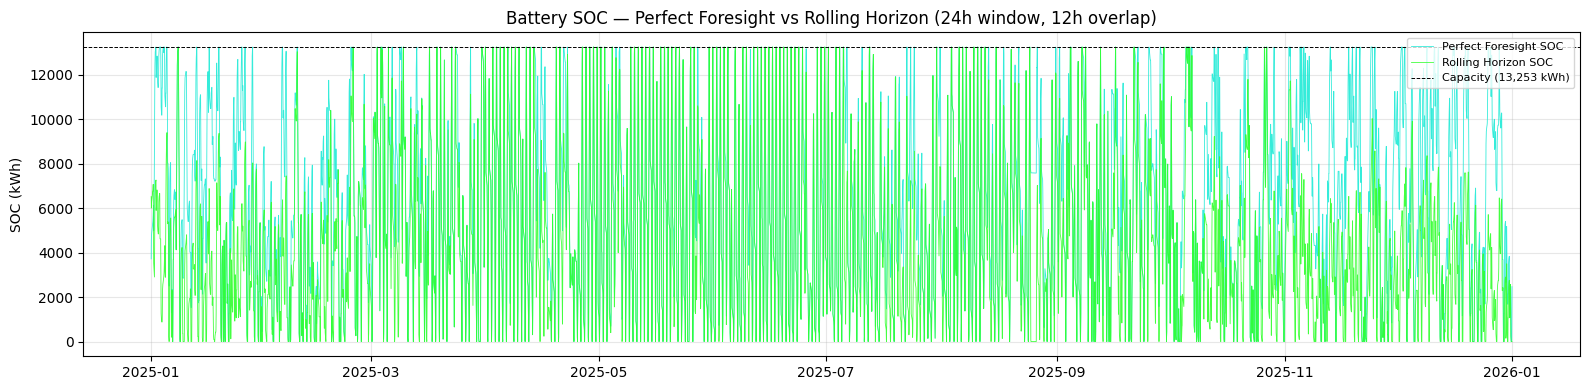

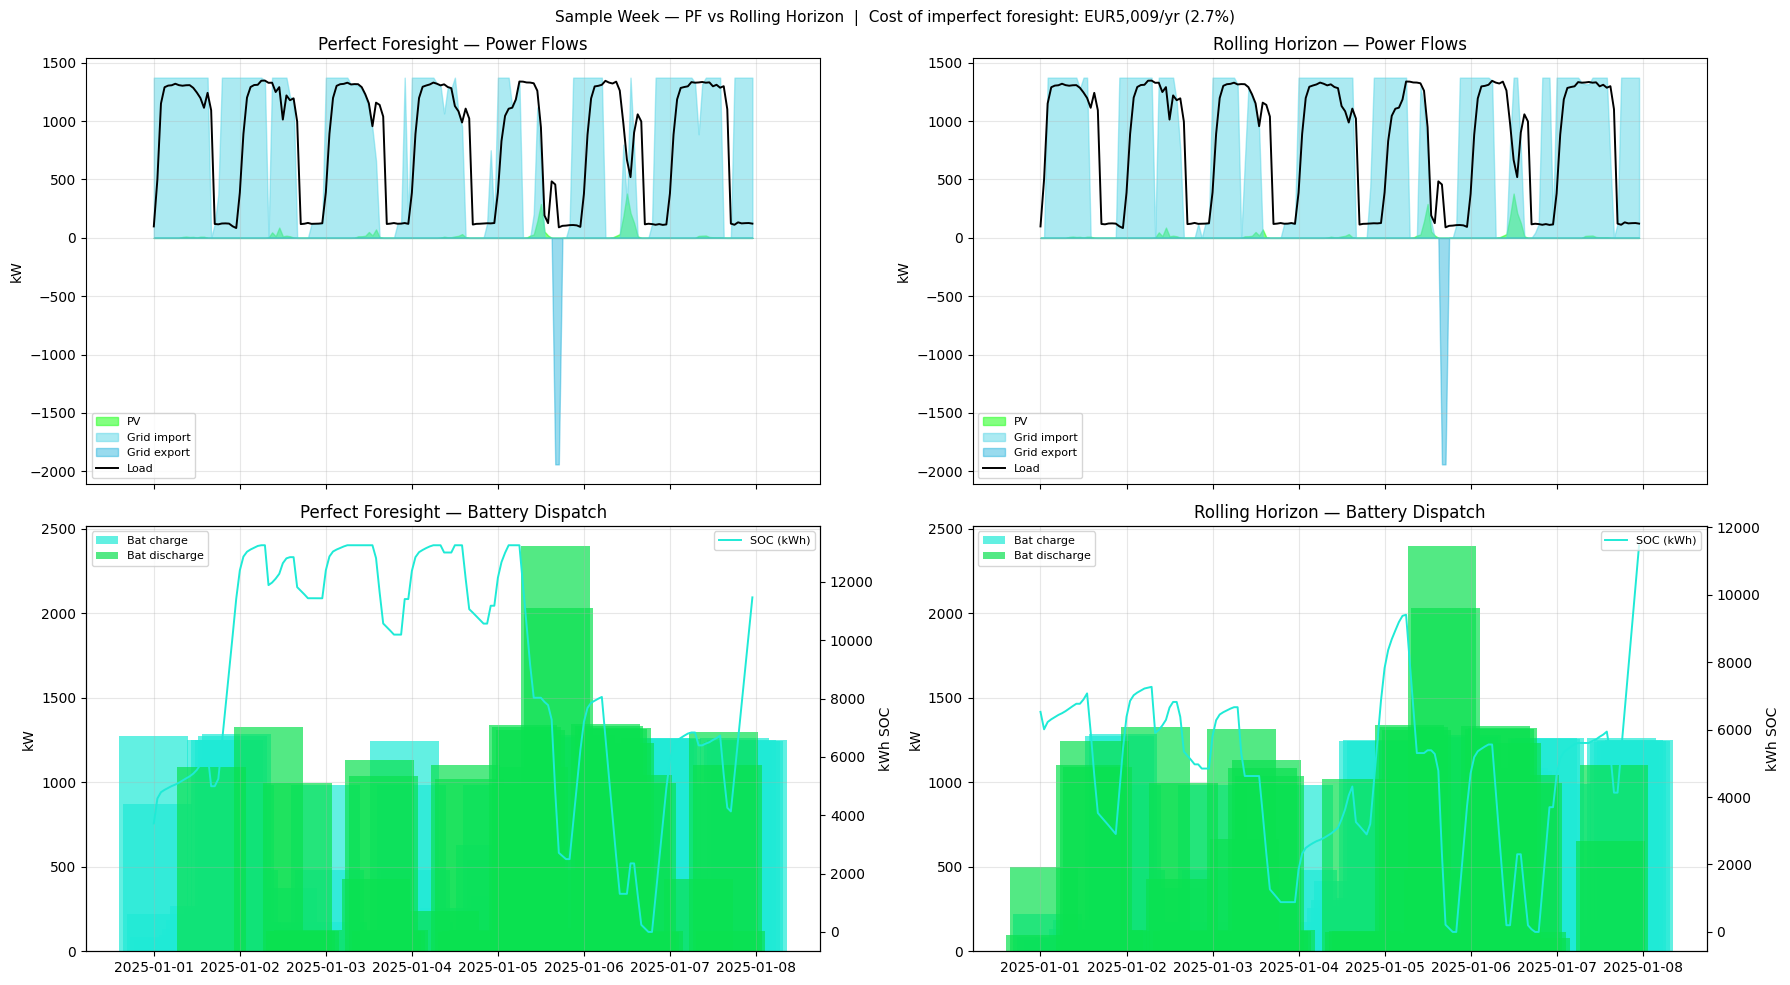

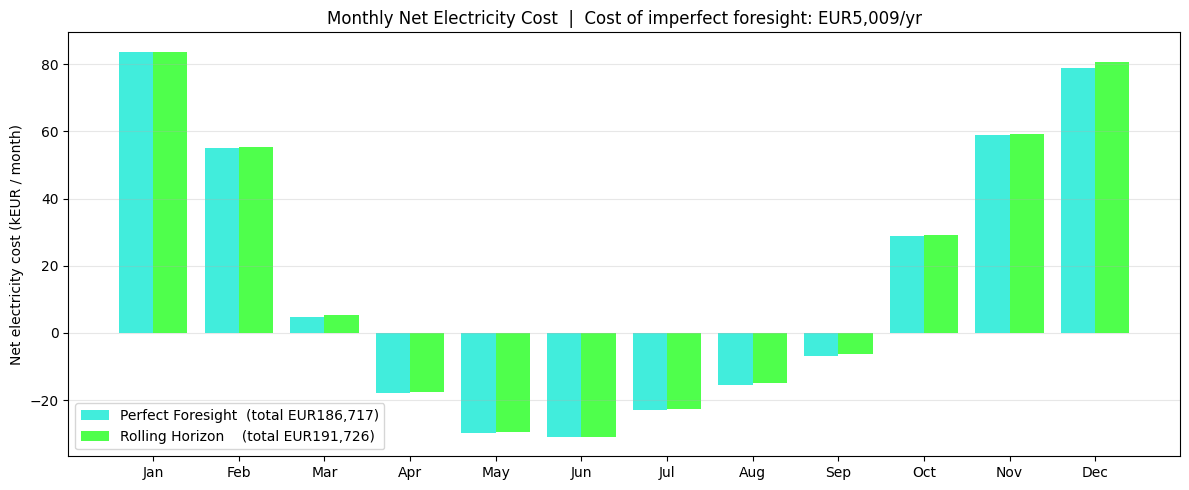

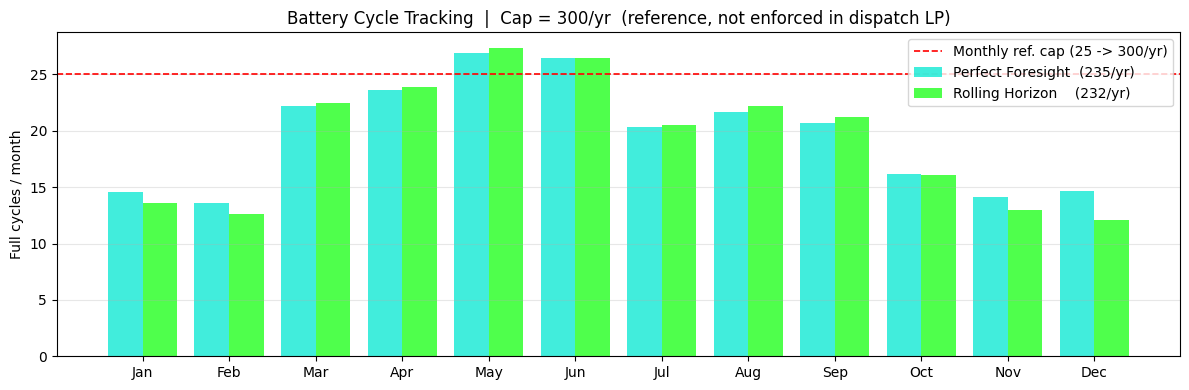

--- Cycle summary ---
  Perfect Foresight :    235 cycles/yr
  Rolling Horizon   :    232 cycles/yr
  Cap (ref.)        :    300 cycles/yr
  Both within cap
Results saved to nl_elec_only_rolling_2025_2026.xlsx


In [17]:
# ══════════════════════════════════════════════════════════════════════
# COMPARISON — Perfect Foresight vs Rolling Horizon
# ══════════════════════════════════════════════════════════════════════

cost_gap = kpi_rh["net_cost"] - kpi_pf["net_cost"]   # positive = RH more expensive
pct_gap  = cost_gap / abs(kpi_pf["net_cost"]) * 100 if kpi_pf["net_cost"] != 0 else 0.0

W = 66
print()
print("=" * W)
print(f"  {'METRIC':<38} {'Perf. Foresight':>12} {'Rolling Horizon':>12}")
print("=" * W)
print(f"  {'Battery (fixed for both)':}")
print(f"  {'  Energy (kWh)':<38} {bat_e_kwh:>12,.0f} {bat_e_kwh:>12,.0f}")
print(f"  {'  Power (kW)':<38} {bat_p_kw:>12,.0f} {bat_p_kw:>12,.0f}")
print(f"  {'  C-rate':<38} {bat_c_rate:>12.2f} {bat_c_rate:>12.2f}")
print("-" * W)
print(f"  {'Grid import (MWh/yr)':<38} {kpi_pf['ei_mwh']:>12.1f} {kpi_rh['ei_mwh']:>12.1f}")
print(f"  {'Grid export (MWh/yr)':<38} {kpi_pf['ee_mwh']:>12.1f} {kpi_rh['ee_mwh']:>12.1f}")
print("-" * W)
print(f"  {'Import cost (EUR/yr)':<38} {kpi_pf['import_cost']:>12,.0f} {kpi_rh['import_cost']:>12,.0f}")
print(f"  {'Export revenue (EUR/yr)':<38} {kpi_pf['export_rev']:>12,.0f} {kpi_rh['export_rev']:>12,.0f}")
print(f"  {'Net electricity cost (EUR/yr)':<38} {kpi_pf['net_cost']:>12,.0f} {kpi_rh['net_cost']:>12,.0f}")
print("-" * W)
print(f"  {'Battery cycles/yr':<38} {kpi_pf['cycles']:>12.0f} {kpi_rh['cycles']:>12.0f}")
print(f"  {'  Cycle cap (tracking ref.)':<38} {MAX_CYCLES_PER_YEAR:>12.0f} {MAX_CYCLES_PER_YEAR:>12.0f}")
over_pf = max(0.0, kpi_pf["cycles"] - MAX_CYCLES_PER_YEAR)
over_rh = max(0.0, kpi_rh["cycles"] - MAX_CYCLES_PER_YEAR)
if over_pf > 0 or over_rh > 0:
    print(f"  {'  Over cap by':<38} {over_pf:>12.0f} {over_rh:>12.0f}")
print("-" * W)
print(f"  {'Self-sufficiency (SS %)':<38} {kpi_pf['ss']:>12.1f} {kpi_rh['ss']:>12.1f}")
print(f"  {'Self-consumption (SC %)':<38} {kpi_pf['sc']:>12.1f} {kpi_rh['sc']:>12.1f}")
print("=" * W)
print(f"  {'Cost of imperfect foresight (EUR/yr)':<38} {cost_gap:>12,.0f}")
print(f"  {'  (as % of PF net cost)':<38} {pct_gap:>11.1f}%")
print("=" * W)
print()


# ══════════════════════════════════════════════════════════════════════
# PLOT 1 — Full-year SOC comparison
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(n_pf.snapshots, d_pf["soc"].values,
        color="#1FEAD6", lw=0.6, alpha=0.9, label="Perfect Foresight SOC")
ax.plot(d_rh["soc"].index, d_rh["soc"].values,
        color="#30FF2C", lw=0.6, alpha=0.9, label="Rolling Horizon SOC")
ax.axhline(bat_e_kwh, color="black", lw=0.7, ls="--",
           label=f"Capacity ({bat_e_kwh:,.0f} kWh)")
ax.set_ylabel("SOC (kWh)")
ax.set_title(f"Battery SOC — Perfect Foresight vs Rolling Horizon "
             f"({RH_HORIZON}h window, {RH_OVERLAP}h overlap)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nl_rolling_soc.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════════════════
# PLOT 2 — Sample week: PF vs RH side by side
# ══════════════════════════════════════════════════════════════════════

_SAMPLE = slice(0, 7 * 24)
_x_wk   = _H[_SAMPLE]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)

for col, (name, d) in enumerate(
    [("Perfect Foresight", d_pf), ("Rolling Horizon", d_rh)]
):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ax_top.fill_between(_x_wk, d["pv"][_SAMPLE],  alpha=0.6, color="#30FF2C", label="PV")
    ax_top.fill_between(_x_wk, d["ei"][_SAMPLE],  alpha=0.5, color="#5AD6E7", label="Grid import")
    ax_top.fill_between(_x_wk, -d["ee"][_SAMPLE], alpha=0.4, color="#00A6D6", label="Grid export")
    ax_top.plot(_x_wk, _load_kw_H[_SAMPLE], color="black", lw=1.4, label="Load")
    ax_top.set_ylabel("kW")
    ax_top.set_title(f"{name} — Power Flows")
    ax_top.legend(fontsize=8)
    ax_top.grid(True, alpha=0.3)

    ax_bot.bar(_x_wk, d["bc"][_SAMPLE], color="#1FEAD6", alpha=0.7, label="Bat charge")
    ax_bot.bar(_x_wk, d["bd"][_SAMPLE], color="#0AE150", alpha=0.7, label="Bat discharge")
    ax2 = ax_bot.twinx()
    ax2.plot(_x_wk, d["soc"][_SAMPLE], color="#1FEAD6", lw=1.4, label="SOC (kWh)")
    ax_bot.set_ylabel("kW"); ax2.set_ylabel("kWh SOC")
    ax_bot.set_title(f"{name} — Battery Dispatch")
    ax_bot.legend(fontsize=8, loc="upper left")
    ax2.legend(fontsize=8, loc="upper right")
    ax_bot.grid(True, alpha=0.3)

plt.suptitle(
    f"Sample Week — PF vs Rolling Horizon  |  "
    f"Cost of imperfect foresight: EUR{cost_gap:,.0f}/yr ({pct_gap:.1f}%)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("nl_rolling_week_dispatch.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════════════════
# PLOT 3 — Monthly net cost comparison
# ══════════════════════════════════════════════════════════════════════

def _monthly_net_cost(d, price_i, price_e, dt_h=1.0):
    cost = (d["ei"] * price_i * dt_h).groupby(d["ei"].index.month).sum()
    rev  = (d["ee"] * price_e * dt_h).groupby(d["ee"].index.month).sum()
    return cost - rev

mc_pf = _monthly_net_cost(d_pf, _import_price_H, _da_price_H)
mc_rh = _monthly_net_cost(d_rh, _import_price_H, _da_price_H)

x12 = np.arange(12)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x12 - 0.2, mc_pf.values / 1000, 0.4, color="#1FEAD6", alpha=0.85,
       label=f"Perfect Foresight  (total EUR{kpi_pf['net_cost']:,.0f})")
ax.bar(x12 + 0.2, mc_rh.values / 1000, 0.4, color="#30FF2C", alpha=0.85,
       label=f"Rolling Horizon    (total EUR{kpi_rh['net_cost']:,.0f})")
ax.set_xticks(x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("Net electricity cost (kEUR / month)")
ax.set_title(f"Monthly Net Electricity Cost  |  Cost of imperfect foresight: EUR{cost_gap:,.0f}/yr")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_rolling_monthly_cost.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════════════════
# PLOT 4 — Monthly battery cycles (tracked, not capped in dispatch LP)
# ══════════════════════════════════════════════════════════════════════

def _monthly_cycles(d, e_nom_kwh, dt_h=1.0):
    bd_monthly = (d["bd"] * dt_h).groupby(d["bd"].index.month).sum()
    return bd_monthly / e_nom_kwh if e_nom_kwh > 0 else bd_monthly * 0

cyc_pf_m = _monthly_cycles(d_pf, bat_e_kwh)
cyc_rh_m = _monthly_cycles(d_rh, bat_e_kwh)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x12 - 0.2, cyc_pf_m.values, 0.4, color="#1FEAD6", alpha=0.85,
       label=f"Perfect Foresight  ({kpi_pf['cycles']:.0f}/yr)")
ax.bar(x12 + 0.2, cyc_rh_m.values, 0.4, color="#30FF2C", alpha=0.85,
       label=f"Rolling Horizon    ({kpi_rh['cycles']:.0f}/yr)")
ax.axhline(MAX_CYCLES_PER_YEAR / 12, color="red", lw=1.2, ls="--",
           label=f"Monthly ref. cap ({MAX_CYCLES_PER_YEAR/12:.0f} -> {MAX_CYCLES_PER_YEAR:.0f}/yr)")
ax.set_xticks(x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("Full cycles / month")
ax.set_title(f"Battery Cycle Tracking  |  Cap = {MAX_CYCLES_PER_YEAR:.0f}/yr  (reference, not enforced in dispatch LP)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_rolling_cycles.png", dpi=150)
plt.show()

print("--- Cycle summary ---")
print(f"  Perfect Foresight : {kpi_pf['cycles']:>6.0f} cycles/yr")
print(f"  Rolling Horizon   : {kpi_rh['cycles']:>6.0f} cycles/yr")
print(f"  Cap (ref.)        : {MAX_CYCLES_PER_YEAR:>6.0f} cycles/yr")
if over_rh > 0:
    print(f"  WARNING: RH exceeds cap by {over_rh:.0f} cycles/yr")
if over_pf > 0:
    print(f"  WARNING: PF exceeds cap by {over_pf:.0f} cycles/yr")
if over_rh == 0 and over_pf == 0:
    print(f"  Both within cap")


# ══════════════════════════════════════════════════════════════════════
# EXCEL EXPORT
# ══════════════════════════════════════════════════════════════════════

_summary = {
    "bat_e_kwh":             bat_e_kwh,
    "bat_p_kw":              bat_p_kw,
    "bat_c_rate":            bat_c_rate,
    "bat_capex_ann_eur":     bat_ann_cap,
    "bat_om_eur":            bat_fix_eur,
    "pf_import_cost_eur":    kpi_pf["import_cost"],
    "pf_export_rev_eur":     kpi_pf["export_rev"],
    "pf_net_cost_eur":       kpi_pf["net_cost"],
    "pf_cycles_yr":          kpi_pf["cycles"],
    "pf_ss_pct":             kpi_pf["ss"],
    "rh_import_cost_eur":    kpi_rh["import_cost"],
    "rh_export_rev_eur":     kpi_rh["export_rev"],
    "rh_net_cost_eur":       kpi_rh["net_cost"],
    "rh_cycles_yr":          kpi_rh["cycles"],
    "rh_ss_pct":             kpi_rh["ss"],
    "cost_of_foresight_eur": cost_gap,
    "cost_of_foresight_pct": pct_gap,
    "cycle_cap_ref":         MAX_CYCLES_PER_YEAR,
    "rh_horizon_h":          RH_HORIZON,
    "rh_overlap_h":          RH_OVERLAP,
}

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    pd.DataFrame([_summary]).T.rename(columns={0: "Value"}).to_excel(
        writer, sheet_name="Summary")
    for label, d in [("PF", d_pf), ("RH", d_rh)]:
        pd.DataFrame({
            "pv_kw":            d["pv"].values,
            "grid_import_kw":   d["ei"].values,
            "grid_export_kw":   d["ee"].values,
            "bat_charge_kw":    d["bc"].values,
            "bat_discharge_kw": d["bd"].values,
            "bat_soc_kwh":      d["soc"].values,
        }, index=d["ei"].index).to_excel(writer, sheet_name=f"Dispatch_{label}")

print(f"Results saved to {OUTPUT_EXCEL}")
